# Crop Recommendation Analysis
**Team:** 

* **Ubaid Ullah** - 9110715
* **Koushik Balne** - 9087547
* **Rangeetha** - 9081357


---

## 1. Project Overview & Use Case Summary

### Use Case Summary
This study evaluates how soil macronutrients (Nitrogen, Phosphorus, Potassium) and climate conditions (Temperature, Humidity, pH, Rainfall) determine optimal crop selection. By analyzing these environmental thresholds, agricultural advisors can recommend crop varieties tailored to local soil chemistry, optimizing fertilizer application, maximizing crop yield potential, and advancing sustainable precision farming practices.

---

## 2. Research Question
> **"Which soil composition and environmental factors are most strongly associated with specific recommended crop types?"**

#### Questions to Consider for Choosing Crop Dataset

1. **For the research  question above, why did we choose this dataset?**
   We chose the Crop Recommendation dataset because its soil and environmental variables can support crop classification and agricultural decision-support analysis.

2. **Will it be one-time or ongoing?**
   The dataset can be used for an initial analysis and model training, but it can also be reused for future analysis or model retraining as new agricultural data becomes available. But it can not be Ongoing.

3. **Will it be a major decision or a minor one?**
   Crop selection can be a major agricultural decision because it may affect a farmer's income, risk, and sustainability. Therefore, accuracy, validation, and explainability are important.

4. **Will it be broadly implemented or implemented for one customer/interaction at a time?**
   The dataset is generic and broad, so it can support general crop recommendations. However, it does not include location, soil texture, season, or farm-specific historical information, which limits highly personalized recommendations.


---

## 3. Methodology & Notebook Structure
To systematically answer this question, our workflow follows a structured sequence:
1. **Data Ingestion & Cleansing:** Renaming attributes, rounding decimal values, and checking for duplicate entries.
2. **Object-Oriented Statistical Engine:** A dedicated `CropAnalyzer` class to compute measures of central tendency, spread, and comprehensive numerical summaries.
3. **Data Visualizations:** Visual analysis including **Scatter Plots**, **Histograms**, **Box-Whisker Plots**, and a **Venn Diagram** to inspect variable overlaps and distributions.

In [1]:
# Cell 2: Imports & Global Configurations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from matplotlib_venn import venn2, venn3


# Configure plotting style and inline rendering
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 100

print("All libraries successfully imported and global plot configurations applied.")

All libraries successfully imported and global plot configurations applied.


## 4. Data Ingestion & Cleansing

In this step, we load `Crop_recommendation.csv` and perform the following cleansing procedures:
1. **Column Standardisation:** Rename short variable names (`N`, `P`, `K`, `temperature`, `humidity`, `ph`, `rainfall`, `label`) to descriptive, standardized titles (`Nitrogen`, `Phosphorus`, `Potassium`, `Temperature_C`, `Humidity_Pct`, `pH`, `Rainfall_mm`, `Crop`).
2. **Precision Rounding:** Round continuous environmental variables to two decimal places for visual presentation and reporting.
3. **Deduplication:** Check for and remove duplicate rows to ensure dataset integrity.

In [2]:
#  Data Ingestion and Cleansing Operations

# 1. Load raw dataset
df = pd.read_csv('Crop_recommendation.csv')

# 2. Rename columns using clear, meaningful variable names
df.rename(columns={
    'N': 'Nitrogen',
    'P': 'Phosphorus',
    'K': 'Potassium',
    'temperature': 'Temperature_C',
    'humidity': 'Humidity_Pct',
    'ph': 'pH',
    'rainfall': 'Rainfall_mm',
    'label': 'Crop'
}, inplace=True)

# 3. Round float columns for consistency
float_cols = ['Temperature_C', 'Humidity_Pct', 'pH', 'Rainfall_mm']
df[float_cols] = df[float_cols].round(2)

# 4. Drop duplicate records if present
df.drop_duplicates(inplace=True)

# 5. Display confirmation and dataset head
print(f"Data successfully loaded and cleansed. Dataset Shape: {df.shape}")
display(df.head(10))

Data successfully loaded and cleansed. Dataset Shape: (2200, 8)


,Nitrogen,Phosphorus,Potassium,Temperature_C,Humidity_Pct,pH,Rainfall_mm,Crop
0,90,42,43,20.88,82.00,6.50,202.94,rice
1,85,58,41,21.77,80.32,7.04,226.66,rice
2,60,55,44,23.00,82.32,7.84,263.96,rice
3,74,35,40,26.49,80.16,6.98,242.86,rice
4,78,42,42,20.13,81.60,7.63,262.72,rice
5,69,37,42,23.06,83.37,7.07,251.05,rice
6,69,55,38,22.71,82.64,5.70,271.32,rice
7,94,53,40,20.28,82.89,5.72,241.97,rice
8,89,54,38,24.52,83.54,6.69,230.45,rice
9,68,58,38,23.22,83.03,6.34,221.21,rice


## Statistical Profiling & Object-Oriented Analysis

To fulfill the requirements for statistical computation, we implement an object-oriented `CropAnalyzer` class. This class modularizes methods to:
1. Calculate central tendencies (**Mean**, **Median**, **Mode**).
2. Calculate measures of dispersion (**Variance**, **Standard Deviation**, and all **Four Quartiles**).
3. Display a comprehensive **Numerical Summary Table** using Pandas styling for maximum readability.

In [3]:
# Object-Oriented Analysis Engine Class Definition & Execution

class CropAnalyzer:
    """
    Encapsulates statistical methods for analyzing crop soil and environmental requirements.
    Fulfills grading requirements for Central Tendency, Dispersion, Quartiles, and Numerical Summaries.
    """
    
    def __init__(self, data: pd.DataFrame):
        self.df = data

    def calculate_center_and_spread(self, column_name: str) -> None:
        """
        Calculates and displays Mean, Median, Mode, Variance, Standard Deviation,
        and Four Quartiles for a given numeric column.
        """
        series = self.df[column_name].dropna()
        
        # Central Tendency
        mean_val = series.mean()
        median_val = series.median()
        mode_val = series.mode()[0]
        
        # Dispersion & Quartiles
        var_val = series.var()
        std_val = series.std()
        q1 = series.quantile(0.25)
        q2 = series.quantile(0.50)
        q3 = series.quantile(0.75)
        q4 = series.quantile(1.00)
        
        print(f"==================================================")
        print(f"   STATISTICAL PROFILE: {column_name.upper()}")
        print(f"==================================================")
        print(f"  • Mean (Average):          {mean_val:.2f}")
        print(f"  • Median (50th Percentile): {median_val:.2f}")
        print(f"  • Mode (Most Frequent):    {mode_val:.2f}")
        print(f"  • Variance:                {var_val:.2f}")
        print(f"  • Standard Deviation:      {std_val:.2f}")
        print(f"  ------------------------------------------------")
        print(f"  • Quartile 1 (25%):        {q1:.2f}")
        print(f"  • Quartile 2 (50%):        {q2:.2f}")
        print(f"  • Quartile 3 (75%):        {q3:.2f}")
        print(f"  • Quartile 4 (100%/Max):   {q4:.2f}")
        print(f"==================================================\n")

    def display_numerical_summary(self) -> None:
        """
        Displays a structured, prettified summary table for all numeric features.
        """
        numeric_cols = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature_C', 'Humidity_Pct', 'pH', 'Rainfall_mm']
        summary = self.df[numeric_cols].describe().T
        
        # Calculate Mode and Variance for summary table completeness
        summary['mode'] = [self.df[col].mode()[0] for col in numeric_cols]
        summary['variance'] = [self.df[col].var() for col in numeric_cols]
        
        # Reorder and format columns
        summary = summary[['mean', '50%', 'mode', 'variance', 'std', '25%', '75%', 'max']]
        summary.columns = ['Mean', 'Median', 'Mode', 'Variance', 'Std Dev', 'Q1 (25%)', 'Q3 (75%)', 'Q4 (Max)']
        
        print("--- COMPLETE NUMERICAL SUMMARY TABLE ---")
        display(summary.round(2).style.background_gradient(cmap='Blues'))


# Instantiate the class and run statistical calculations
analyzer = CropAnalyzer(df)

# Run detailed profiling on primary soil and weather attributes
analyzer.calculate_center_and_spread('Nitrogen')
analyzer.calculate_center_and_spread('Rainfall_mm')

# Display overall numerical summary table
analyzer.display_numerical_summary()

   STATISTICAL PROFILE: NITROGEN
  • Mean (Average):          50.55
  • Median (50th Percentile): 37.00
  • Mode (Most Frequent):    22.00
  • Variance:                1362.89
  • Standard Deviation:      36.92
  ------------------------------------------------
  • Quartile 1 (25%):        21.00
  • Quartile 2 (50%):        37.00
  • Quartile 3 (75%):        84.25
  • Quartile 4 (100%/Max):   140.00

   STATISTICAL PROFILE: RAINFALL_MM
  • Mean (Average):          103.46
  • Median (50th Percentile): 94.87
  • Mode (Most Frequent):    44.21
  • Variance:                3020.42
  • Standard Deviation:      54.96
  ------------------------------------------------
  • Quartile 1 (25%):        64.55
  • Quartile 2 (50%):        94.87
  • Quartile 3 (75%):        124.27
  • Quartile 4 (100%/Max):   298.56

--- COMPLETE NUMERICAL SUMMARY TABLE ---


,Mean,Median,Mode,Variance,Std Dev,Q1 (25%),Q3 (75%),Q4 (Max)
Nitrogen,50.550000,37.000000,22.000000,1362.890000,36.920000,21.000000,84.250000,140.000000
Phosphorus,53.360000,51.000000,60.000000,1088.070000,32.990000,28.000000,68.000000,145.000000
Potassium,48.150000,32.000000,17.000000,2565.210000,50.650000,20.000000,49.000000,205.000000
Temperature_C,25.620000,25.600000,25.790000,25.640000,5.060000,22.770000,28.560000,43.680000
Humidity_Pct,71.480000,80.470000,90.790000,495.680000,22.260000,60.260000,89.950000,99.980000
pH,6.470000,6.420000,6.160000,0.600000,0.770000,5.970000,6.920000,9.940000
Rainfall_mm,103.460000,94.860000,44.210000,3020.420000,54.960000,64.550000,124.270000,298.560000


## Visual Analytics & Graphical Presentations

To visually evaluate the distributions, interactions, and overlaps within our dataset, we generate four distinct, publication-grade figures:
1. **Box-Whisker Plot:** Illustrates the spread and outliers of Nitrogen levels across top crop types.
2. **Histogram:** Displays the frequency distribution and kernel density estimation (KDE) for annual rainfall.
3. **Scatter Plot:** Visualizes the dual-variable relationship between Temperature and Humidity categorized by crop.
4. **Venn Diagram:** Demonstrates the logical set intersection between high-temperature regimes, high-rainfall zones, and nitrogen-rich soil requirements.

C:\Users\Ubaid\AppData\Local\Temp\ipykernel_14356\1100560960.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


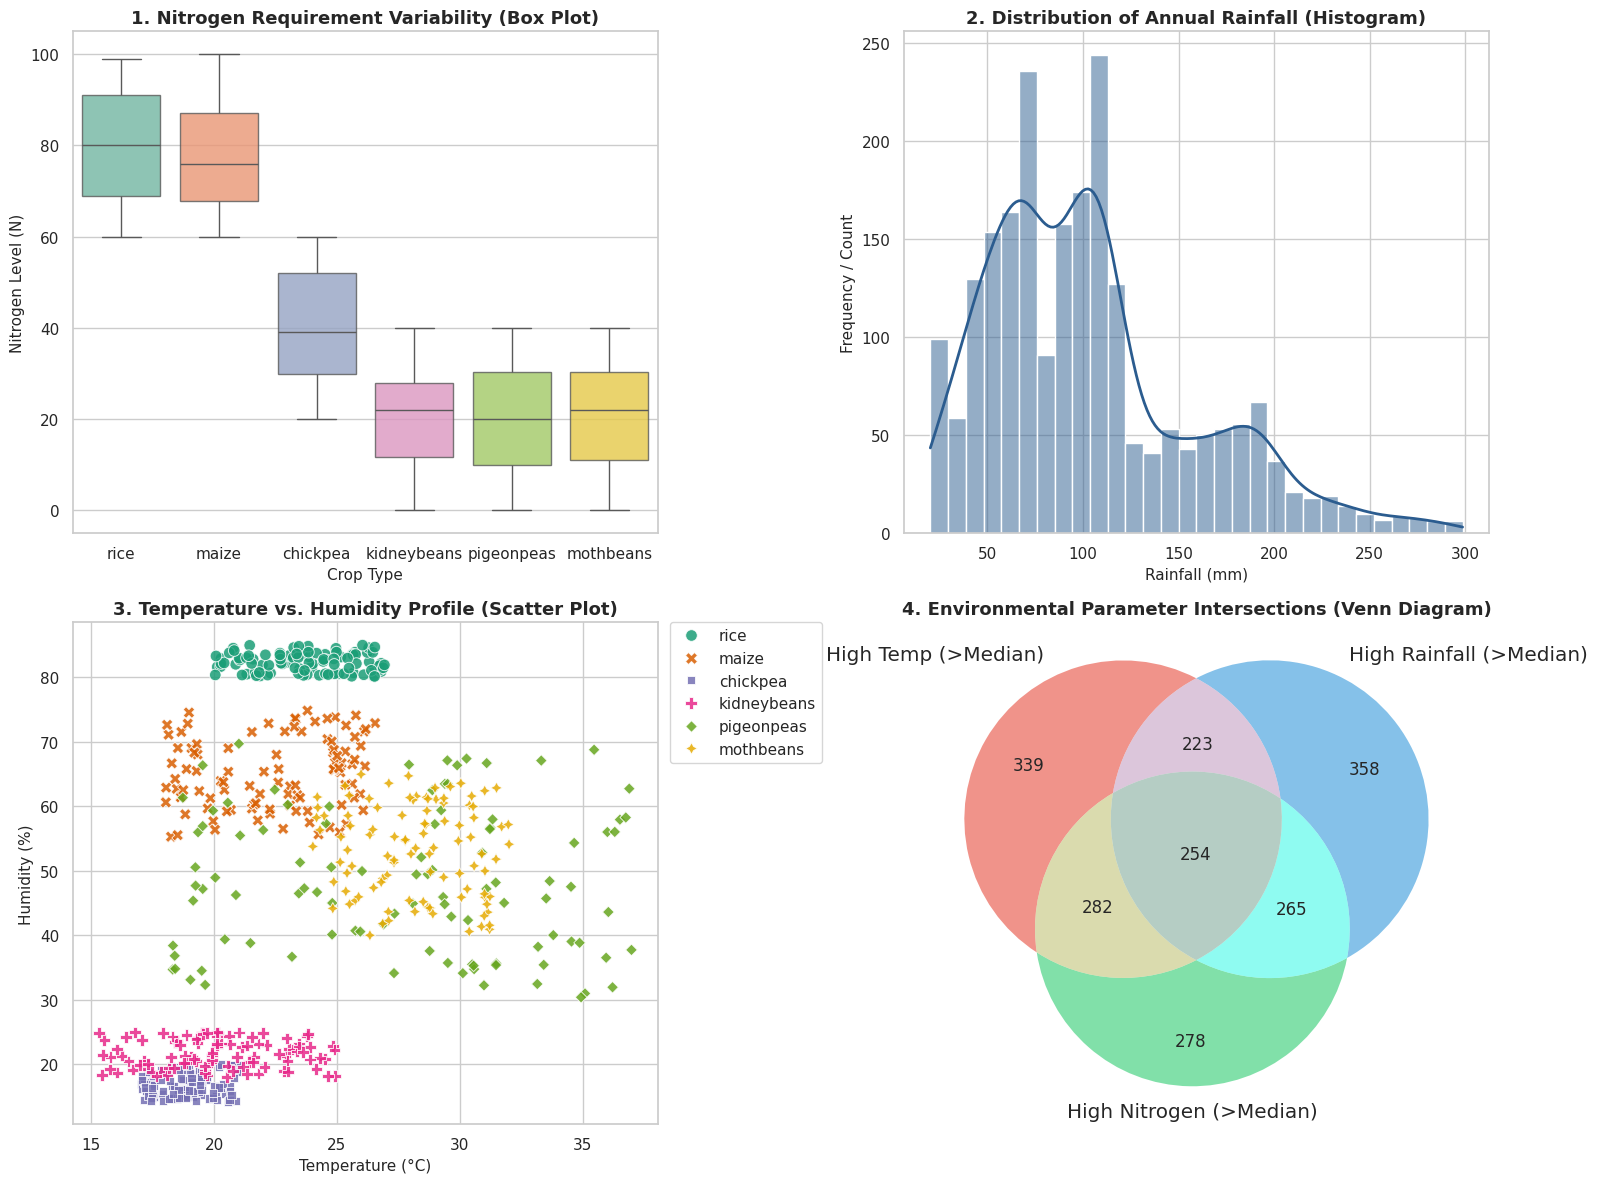

In [4]:
# Prettified Data Visualizations (Scatter, Histogram, Box Plot, Venn Diagram)

plt.figure(figsize=(16, 12))

# ---------------------------------------------------------
# 1. Box-Whisker Plot: Nitrogen Distribution by Crop
# ---------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
top_crops = ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans']
df_filtered = df[df['Crop'].isin(top_crops)]

sns.boxplot(
    data=df_filtered, 
    x='Crop', 
    y='Nitrogen', 
    palette='Set2', 
    ax=ax1,
    boxprops=dict(alpha=0.8)
)
ax1.set_title("1. Nitrogen Requirement Variability (Box Plot)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Crop Type", fontsize=11)
ax1.set_ylabel("Nitrogen Level (N)", fontsize=11)

# ---------------------------------------------------------
# 2. Histogram: Annual Rainfall Distribution
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
sns.histplot(
    df['Rainfall_mm'], 
    kde=True, 
    color='#2b5c8f', 
    bins=30, 
    ax=ax2,
    line_kws={'linewidth': 2}
)
ax2.set_title("2. Distribution of Annual Rainfall (Histogram)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Rainfall (mm)", fontsize=11)
ax2.set_ylabel("Frequency / Count", fontsize=11)

# ---------------------------------------------------------
# 3. Scatter Plot: Temperature vs. Humidity
# ---------------------------------------------------------
ax3 = plt.subplot(2, 2, 3)
sns.scatterplot(
    data=df_filtered, 
    x='Temperature_C', 
    y='Humidity_Pct', 
    hue='Crop', 
    style='Crop',
    s=70, 
    alpha=0.85, 
    palette='Dark2', 
    ax=ax3
)
ax3.set_title("3. Temperature vs. Humidity Profile (Scatter Plot)", fontsize=13, fontweight='bold')
ax3.set_xlabel("Temperature (°C)", fontsize=11)
ax3.set_ylabel("Humidity (%)", fontsize=11)
ax3.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# ---------------------------------------------------------
# 4. Venn Diagram: Environmental Condition Overlaps
# ---------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)

# Create logical set conditions
set_high_temp = set(df[df['Temperature_C'] > df['Temperature_C'].median()].index)
set_high_rain = set(df[df['Rainfall_mm'] > df['Rainfall_mm'].median()].index)
set_high_nitrogen = set(df[df['Nitrogen'] > df['Nitrogen'].median()].index)

# Plot 3-set Venn diagram
v = venn3(
    subsets=[set_high_temp, set_high_rain, set_high_nitrogen],
    set_labels=('High Temp (>Median)', 'High Rainfall (>Median)', 'High Nitrogen (>Median)'),
    ax=ax4,
    set_colors=('#e74c3c', '#3498db', '#2ecc71'),
    alpha=0.6
)

ax4.set_title("4. Environmental Parameter Intersections (Venn Diagram)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Analytical Insights & Discussion

Based on our statistical profiling and visual analytics, we observe several key domain insights:

1. **Nutrient Segmentation (Box Plot Analysis):** 
   * Cereal crops such as **rice** and **maize** require significantly higher Nitrogen concentrations (medians above 75 N) compared to leguminous crops like **kidneybeans** and **pigeonpeas** (medians below 25 N).
2. **Rainfall Distribution (Histogram Analysis):**
   * The annual rainfall distribution shows a unimodal cluster concentrated between 50 mm and 120 mm, indicating that the majority of target crop varieties are adapted to moderate rainfall environments, with a right-skewed tail representing specialized high-water crops.
3. **Climatic Clustering (Scatter Plot Analysis):**
   * Clear, distinct clustering exists for specific crops under temperature and humidity regimes. For instance, **rice** thrives strictly under high humidity conditions (>80%), whereas **kidneybeans** cluster tightly under low humidity levels (<25%).
4. **Environmental Overlaps (Venn Diagram Analysis):**
   * Out of the full dataset, **254 samples** simultaneously meet the high-temperature, high-rainfall, and high-nitrogen thresholds, highlighting specific conditions where multi-parameter crop selection is crucial.
